In [1]:
import nltk
nltk.download('punkt')        # For tokenization
nltk.download('stopwords')    # For stop words
nltk.download('wordnet')      # For lemmatization
nltk.download('averaged_perceptron_tagger') # For POS tagging
nltk.download('omw-1.4')      # For WordNet data
nltk.download('punkt_tab') 

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [2]:
import re
import string
from nltk.tokenize import sent_tokenize, word_tokenize
import spacy

--> Image Acquisition

--> Image Processing

--> Image Data representation

    --> Represent the image as a matrix
    -->  Black and white; color

--> Image Analysis

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import img_as_ubyte
from skimage.color import gray2rgb

In [4]:
pixel_values = [
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 255, 0, 0, 0, 0, 255, 0, 0],   # eyes: left open, right winking
    [0, 0, 255, 0, 0, 0, 0, 0, 0, 0],     # left eye line continues
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],       # empty line
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],       # empty line
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],       # empty line
    [0, 255, 0, 0, 0, 0, 0, 0, 255, 0],   # sides of smile
    [0, 0, 255, 0, 0, 0, 0, 255, 0, 0],   # curved middle
    [0, 0, 0, 255, 255, 255, 255, 0, 0, 0], # bottom of smile
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
]

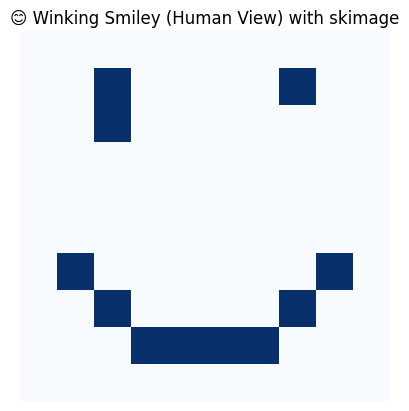

🤖 Pixel Values (How Computer Sees It):

[[  0   0   0   0   0   0   0   0   0   0]
 [  0   0 255   0   0   0   0 255   0   0]
 [  0   0 255   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0]
 [  0 255   0   0   0   0   0   0 255   0]
 [  0   0 255   0   0   0   0 255   0   0]
 [  0   0   0 255 255 255 255   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0]]


In [11]:
image_array = np.array(pixel_values, dtype=np.uint8)

plt.imshow(image_array, cmap='Blues')
plt.title("😊 Winking Smiley (Human View) with skimage")
plt.axis('off')
plt.show()

# Print pixel values (how computer sees it)
print("🤖 Pixel Values (How Computer Sees It):\n")
print(image_array)

🟦 RGB Image Shape: (796, 800, 3)
⬛ Grayscale Image Shape: (796, 800)
🎨 HSV Image Shape: (796, 800, 3)


C:\Users\user\AppData\Local\Temp\ipykernel_9856\1095218437.py:51: UserWarning: Glyph 127752 (\N{RAINBOW}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_9856\1095218437.py:51: UserWarning: Glyph 128420 (\N{BLACK HEART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_9856\1095218437.py:51: UserWarning: Glyph 127912 (\N{ARTIST PALETTE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127752 (\N{RAINBOW}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\user\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128420 (\N{BLACK HEART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\user\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools

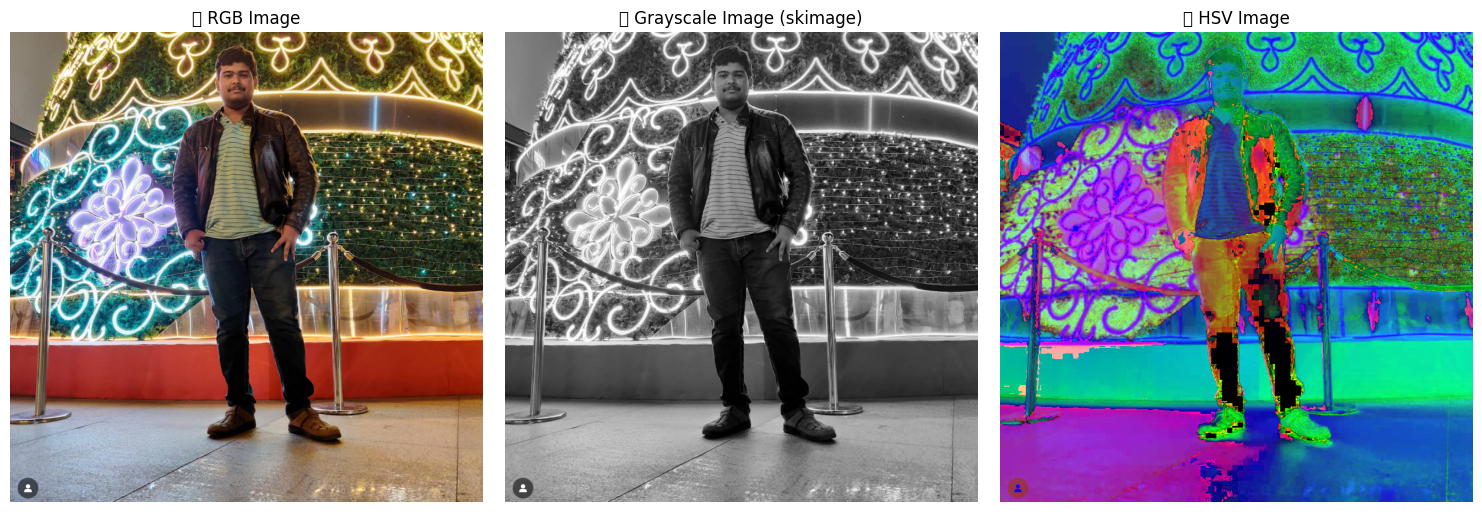

In [4]:
# STEP 1: Import libraries
from skimage import io, color
import numpy as np
import matplotlib.pyplot as plt
import os

# STEP 2: Ask user to upload or use default image
choice = input("Do you want to provide a path to an image? (yes/no): ").lower()

if choice == 'yes':
    # Ask for file path relative to current directory
    filename = input("Enter image filename (e.g., 'image.jpg'): ")
    filepath = os.path.join(r"C:\Users\user\Desktop\Spring Test\Scal\Lecture Notes\AI_ML Module", filename)
    img_rgb = io.imread(filepath)[:,:,:3]
else:
    # Use default image (put it in the same folder or adjust path accordingly)
    default_filename = "Pic1.png"
    filepath = os.path.join(r"C:\Users\user\Desktop\Spring Test\Scal\Lecture Notes\AI_ML Module", default_filename)
    img_rgb = io.imread(filepath)[:,:,:3]

# STEP 3: Convert to grayscale and HSV using skimage
img_gray = color.rgb2gray(img_rgb)
img_hsv = color.rgb2hsv(img_rgb)

# STEP 4: Show the shapes
print("🟦 RGB Image Shape:", img_rgb.shape)       # (H, W, 3)
print("⬛ Grayscale Image Shape:", img_gray.shape) # (H, W)
print("🎨 HSV Image Shape:", img_hsv.shape)       # (H, W, 3)

# STEP 5: Display all using subplot
plt.figure(figsize=(15, 5))

# RGB
plt.subplot(1, 3, 1)
plt.imshow(img_rgb)
plt.title("🌈 RGB Image")
plt.axis('off')

# Grayscale
plt.subplot(1, 3, 2)
plt.imshow(img_gray, cmap='gray')
plt.title("🖤 Grayscale Image (skimage)")
plt.axis('off')

# HSV
plt.subplot(1, 3, 3)
plt.imshow(img_hsv)
plt.title("🎨 HSV Image")
plt.axis('off')

plt.tight_layout()
plt.show()


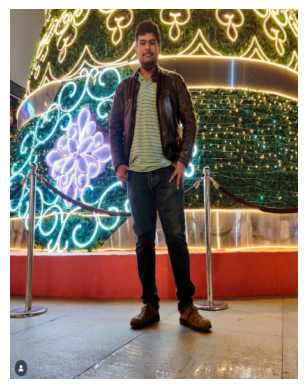

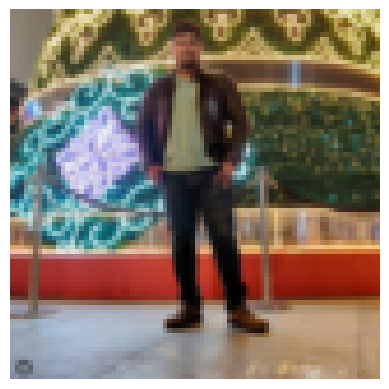

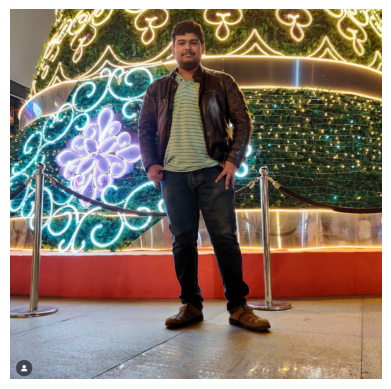

(796, 800, 3)
(80, 80, 3)


In [13]:
from skimage import transform
import matplotlib.pyplot as plt

rescaled_image = transform.resize(img_rgb, (531, 413))
plt.imshow(rescaled_image)
plt.axis('off')
plt.show()
image1 = transform.rescale(img_rgb, 0.1,channel_axis=-1)
plt.imshow(image1)
plt.axis('off')
plt.show()
plt.imshow(img_rgb)
plt.axis('off')
plt.show()

print(img_rgb.shape)
print(image1.shape)